# Cell Painting protocol variants → AnnData

Protocol variations on the same compound set ([`cpg0001`](https://broadinstitute.github.io/cellpainting-gallery/)). Feature selection ran per batch and the batches share **no** features at all, so intersecting across them yields an empty matrix and a single batch has to be used.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select.csv.gz" \
  s3://cellpainting-gallery/cpg0001-cellpainting-protocol/source_4/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0001-cellpainting-protocol/profiles").expanduser()

## Scoping to one batch

Feature selection ran per batch, so batches carry different feature sets and intersecting across them throws most features away.
This takes the batch with the most plates.

In [2]:
batches = sorted({p.parents[1].name for p in PROFILES.glob("*/*/*.csv.gz")})
BATCH = max(batches, key=lambda b: len(list((PROFILES / b).glob("*/*"))))
print(f"{len(batches)} batches, using {BATCH}")
files = sorted((PROFILES / BATCH).glob("*/*"))

36 batches, using Stain5_AZ


In [3]:
adata = cpio.read_profiles(
    files, index_columns=["batch", "Plate", "Well"], path_columns={"batch": 2}, on_column_mismatch="intersect"
)
adata

AnnData object with n_obs × n_vars = 5794 × 187
    obs: 'plate_map_name', 'broad_sample', 'solvent', 'Astrazeneca_Sampleid', 'Plate', 'Well', 'InChIKey', 'pert_iname', 'smiles', 'pubchem_cid', 'moa', 'pert_type', 'control_type', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


for column in present(["Plate", "pert_type", "control_type", "moa"]):
    adata.obs[column] = adata.obs[column].astype("category")
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Nuclei_Areashape_Centralmoment_0_1,nuclei,areashape,NaN,NaN,0
Nuclei_Areashape_Centralmoment_0_3,nuclei,areashape,NaN,NaN,0
Nuclei_Areashape_Centralmoment_1_0,nuclei,areashape,NaN,NaN,0
Nuclei_Areashape_Centralmoment_1_2,nuclei,areashape,NaN,NaN,0
Nuclei_Areashape_Centralmoment_2_1,nuclei,areashape,NaN,NaN,0
...,...,...,...,...,...
Cytoplasm_Radialdistribution_Radialcv_Mito_1Of4,cytoplasm,radialdistribution,mito,NaN,1
Cytoplasm_Radialdistribution_Radialcv_Mito_3Of4,cytoplasm,radialdistribution,mito,NaN,1
Cytoplasm_Radialdistribution_Radialcv_Mito_4Of4,cytoplasm,radialdistribution,mito,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["pert_type", "moa"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

5,794 wells x 187 features
non-finite: 0 | max|x|: 9695.8

pert_type:
pert_type
trt        5242
control     552

moa:
moa
<NA>                                 552
acetylcholine receptor antagonist    276
EGFR inhibitor                       184
LXR agonist                          184
MAP kinase inhibitor                 184
MEK inhibitor                        184


In [6]:
adata.write_h5ad(PROFILES.parent / "cellpainting_protocol.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate", "pert_type", "control_type", "moa"]))

,observed,baseline,ratio
covariate,,,
Plate,0.050,0.043,1.155
pert_type,0.888,0.828,1.073
control_type,1.000,0.500,2.000
moa,0.458,0.030,15.339


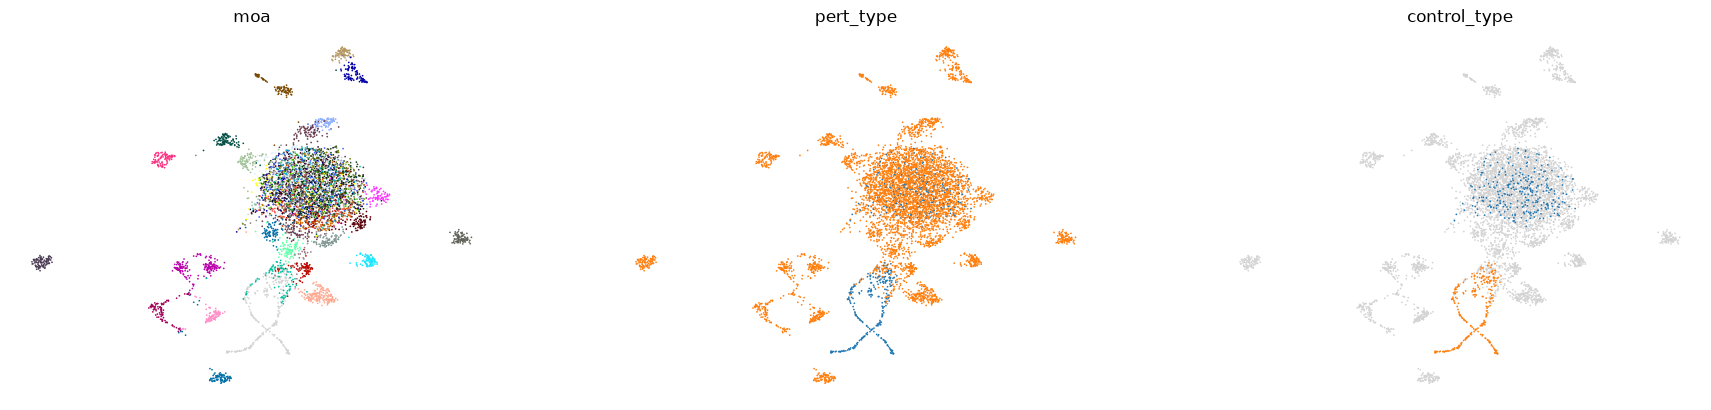

In [9]:
colours = present(["moa", "pert_type", "control_type"])[:3] or None
crowded = bool(colours) and max(adata.obs[c].nunique() for c in colours) > 20
sc.pl.umap(adata, color=colours, ncols=3, frameon=False, size=6, legend_loc="none" if crowded else "right margin")